<div style = "font-size: 36px;">Import Library</div>
<div style = "font-size: 14px; color: #9497a1;">นำเข้าไลบรารีต่างๆ</div>

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

<div style = "font-size: 36px;">Data preprocessing & Data cleansing & Handling Missing Values</div>
<div style = "font-size: 14px; color: #9497a1;">เตรียมข้อมูล ทำความสะอาดข้อมูล และจัดการค่าที่หายไป</div>

In [130]:
data = pd.read_csv("C:\\Users\\vachi\\OneDrive\\Desktop\\codingSKT\\website\\model-py\\dataset.csv")

data = data.drop(0)
data = data.replace("-", pd.NA)
data.fillna(0, inplace = True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors = "coerce")

C:\Users\vachi\AppData\Local\Temp\ipykernel_12312\1900739753.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.fillna(0, inplace = True)


<div style = "font-size: 36px;">Define Feature & Label</div>
<div style = "font-size: 14px; color: #9497a1;">กำหนด Feature และ Label</div>

In [131]:
X1 = ["thai_1", "english_basic_1", "english_add_1", "math_basic_1", "math_add_1", "science_1", "physics_1", "chemistry_1", "biology_1", "computer_1", "robot_1", "project_1", "social1_1", "social2_1", "health_1", "pe_1", "art_1", "career_1", "credits_studied_1", "credits_earned_1", "gpa_1"]
X2 = ["thai_2", "english_basic_2", "english_add_2", "math_basic_2", "math_add_2", "science_2", "physics_2", "chemistry_2", "biology_2", "computer_2", "robot_2", "social1_2", "social2_2", "health_2", "pe_2", "art_2", "career_2", "credits_studied_2", "credits_earned_2", "gpa_2"]
X3 = ["thai_3", "english_basic_3", "english_add_3", "math_basic_3", "math_add_3", "science_3", "physics_3", "chemistry_3", "biology_3", "computer_3", "robot_3", "social1_3", "social2_3", "health_3", "pe_3", "art_3", "career_3", "credits_studied_3", "credits_earned_3", "gpa_3"]
X4 = ["thai_4", "english_basic_4", "english_add_4", "math_basic_4", "math_add_4", "science_4", "physics_4", "chemistry_4", "biology_4", "computer_4", "robot_4", "social1_4", "social2_4", "health_4", "pe_4", "art_4", "career_4", "credits_studied_4", "credits_earned_4", "gpa_4"]
X5 = ["thai_5", "english_basic_5", "english_add_5", "math_basic_5", "math_add_5", "science_5", "physics_5", "chemistry_5", "biology_5", "computer_5", "social1_5", "social2_5", "health_5", "pe_5", "art_5", "credits_studied_5", "credits_earned_5", "gpa_5"]

X5 = X1 + X2 + X3 + X4 + X5

X_array = [X5, X5, X5, X5]
y_array = ["gpa_6", "gpa_6", "gpa_6", "gpa_6"]

<div style = "font-size: 36px;">Train-Test Split</div>
<div style = "font-size: 14px; color: #9497a1;">แบ่ง Train และ Test</div>

In [132]:
random_state_split_array = [42, 42, 42, 45]
X_train_array = []
X_test_array = []
y_train_array = []
y_test_array = []

for i in range(len(X_array)):
    X_train, X_test, y_train, y_test = train_test_split(data[X_array[i]], data[y_array[i]], test_size = 0.2, random_state = random_state_split_array[i])

    X_train = X_train.apply(pd.to_numeric, errors = "coerce").fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors = "coerce").fillna(0)
    y_train = y_train.apply(pd.to_numeric, errors = "coerce").fillna(0)
    y_test = y_test.apply(pd.to_numeric, errors = "coerce").fillna(0)

    X_train_array.append(X_train)
    X_test_array.append(X_test)
    y_train_array.append(y_train)
    y_test_array.append(y_test)

<div style = "font-size: 36px;">Model Training</div>
<div style = "font-size: 14px; color: #9497a1;">สร้างและฝึกโมเดล</div>

In [133]:
# Decision Tree Regression
modelDecisionTreeRegression = DecisionTreeRegressor(random_state = 44, max_depth = 5)
modelDecisionTreeRegression.fit(X_train_array[0], y_train_array[0])

#Linear Regression
modelLinearRegression = LinearRegression()
modelLinearRegression.fit(X_train_array[1], y_train_array[1])

# Polynomial Regression
modelPolynomialRegression = make_pipeline(PolynomialFeatures(degree = 2), LinearRegression())
modelPolynomialRegression.fit(X_train_array[2], y_train_array[2])

# Regularized Linear Regression (Ridge)
modelRegularizedLinearRegression_Ridge = Ridge(alpha = 1, random_state = 42)
modelRegularizedLinearRegression_Ridge.fit(X_train_array[3], y_train_array[3])

modelArray = [modelDecisionTreeRegression, modelLinearRegression, modelPolynomialRegression, modelRegularizedLinearRegression_Ridge]

<div style = "font-size: 36px;">Model Prediction</div>
<div style = "font-size: 14px; color: #9497a1;">ทำนายผล</div>

In [134]:
y_preds = []

for i in range(len(modelArray)):
    y_pred = modelArray[i].predict(X_test_array[i])
    y_preds.append(y_pred)

<div style = "font-size: 36px;">Model Evaluation</div>
<div style = "font-size: 14px; color: #9497a1;">ประเมินผลโมเดล</div>

In [135]:
r2Array = []
mseArray = []
rmseArray = []
maeArray = []
modelNameArray = [
    "Decision Tree Regression",
    "Linear Regression",
    "Polynomial Regression",
    "Regularized Linear Regression (Ridge)"
]

for i in range(len(modelArray)):
    r2 = modelArray[i].score(X_test_array[i], y_test_array[i])
    mse = mean_squared_error(y_test_array[i], y_preds[i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_array[i], y_preds[i])

    r2Array.append(r2)
    mseArray.append(mse)
    rmseArray.append(rmse)
    maeArray.append(mae)
    
for i in range(len(modelArray)):
    print(f"{modelNameArray[i]}:\n\tR² = {r2Array[i]}%\n\tMSE = {mseArray[i]}\n\t√MSE = {rmseArray[i]}\n\tMAE = {maeArray[i]}")

Decision Tree Regression:
	R² = 0.9826831407793198%
	MSE = 0.03805055555555558
	√MSE = 0.1950655160594911
	MAE = 0.08316666666666665
Linear Regression:
	R² = 0.9619345973888029%
	MSE = 0.08364159449146663
	√MSE = 0.289208565729763
	MAE = 0.16139751291965945
Polynomial Regression:
	R² = 0.9931482104183329%
	MSE = 0.01505552460811419
	√MSE = 0.12270095601956078
	MAE = 0.06111713329759798
Regularized Linear Regression (Ridge):
	R² = 0.9896611590352529%
	MSE = 0.02123799283086839
	√MSE = 0.14573260730141482
	MAE = 0.10225215387252935


<div style = "font-size: 36px;">Models Graph</div>
<div style = "font-size: 14px; color: #9497a1;">กราฟของโมเดลแต่ละแบบ</div>

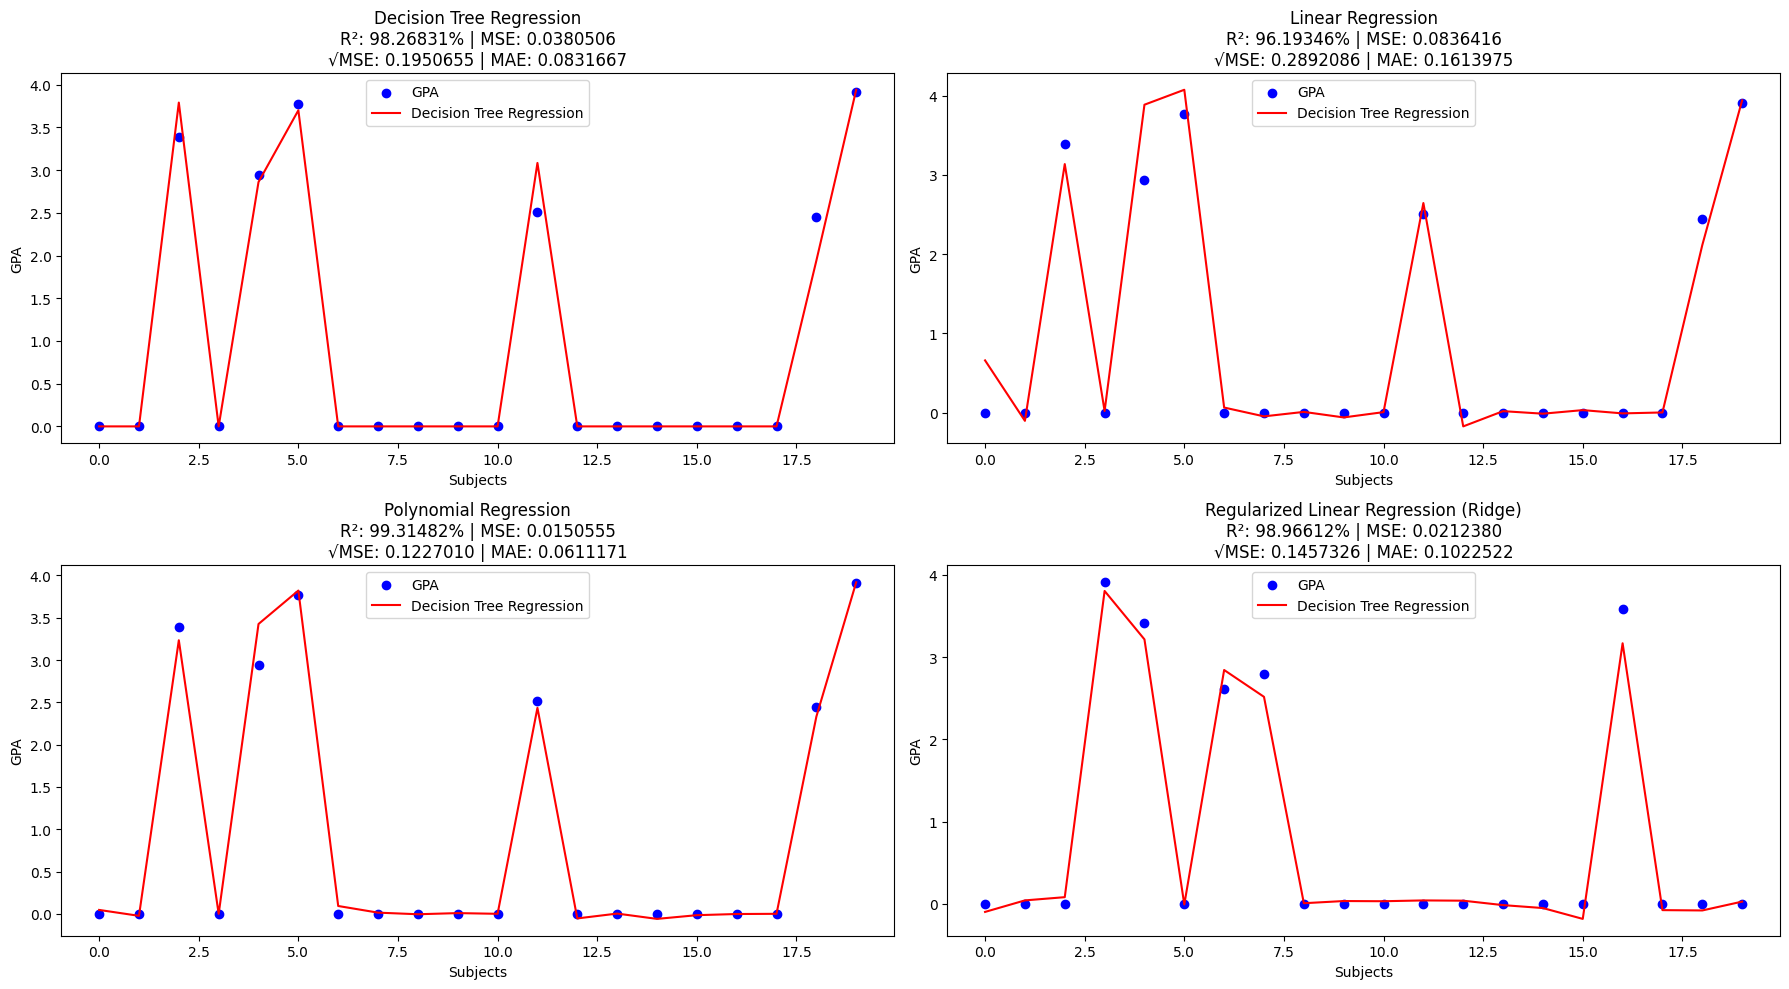

In [136]:
fig, axes = plt.subplots(2, 2, figsize = (18, 10))
axes = axes.flatten()

for i in range(len(modelArray)):
    r2 = r2Array[i] * 100 if r2Array[i] >= 0 else r2Array[i]

    ax = axes[i]
    ax.scatter(range(len(y_test_array[i])), y_test_array[i], color = "blue", label = "GPA")
    ax.plot(range(len(y_test_array[i])), y_preds[i], color = "red", label = "Decision Tree Regression")
    ax.set_title(f"{modelNameArray[i]}\nR²: {r2:.5f}% | MSE: {mseArray[i]:.7f}\n√MSE: {rmseArray[i]:.7f} | MAE: {maeArray[i]:.7f}")
    ax.set_xlabel("Subjects")
    ax.set_ylabel("GPA")
    ax.legend()

plt.tight_layout()
plt.show()